<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/Ridge_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (200, 4)

First 5 Rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Training Data: (160, 3)
Testing Data: (40, 3)

RIDGE REGRESSION RESULTS
R² Score       : 0.9057
R² Score (%)   : 90.57%
MAE            : 1.2734
RMSE           : 1.7074


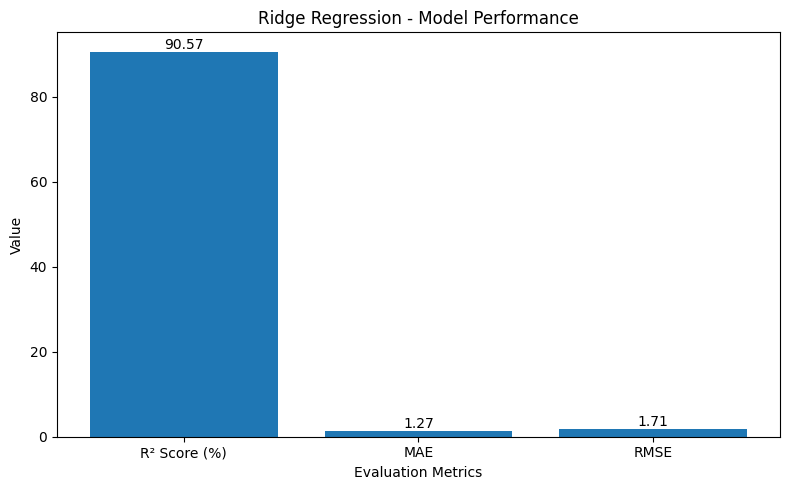

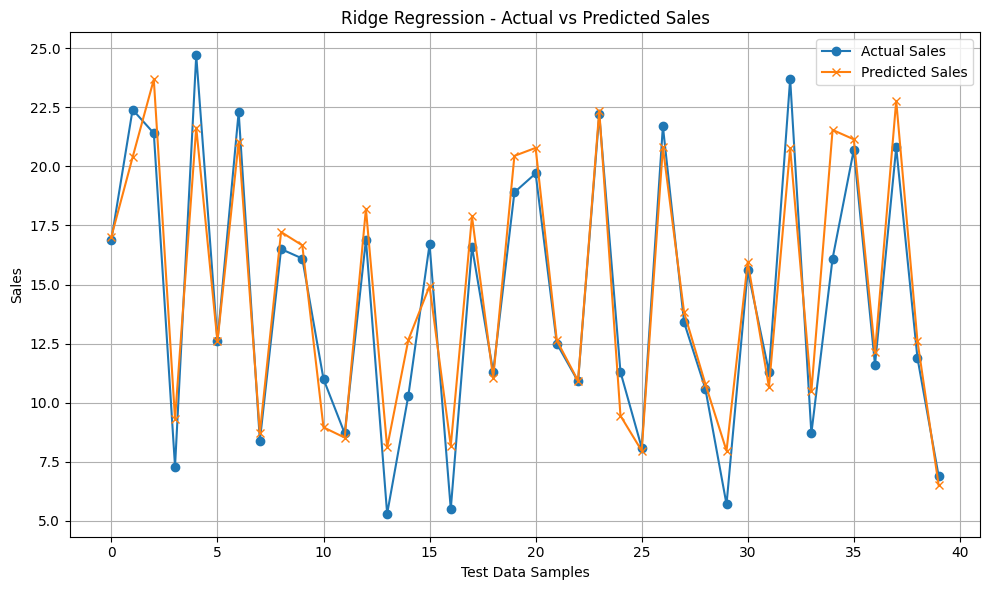

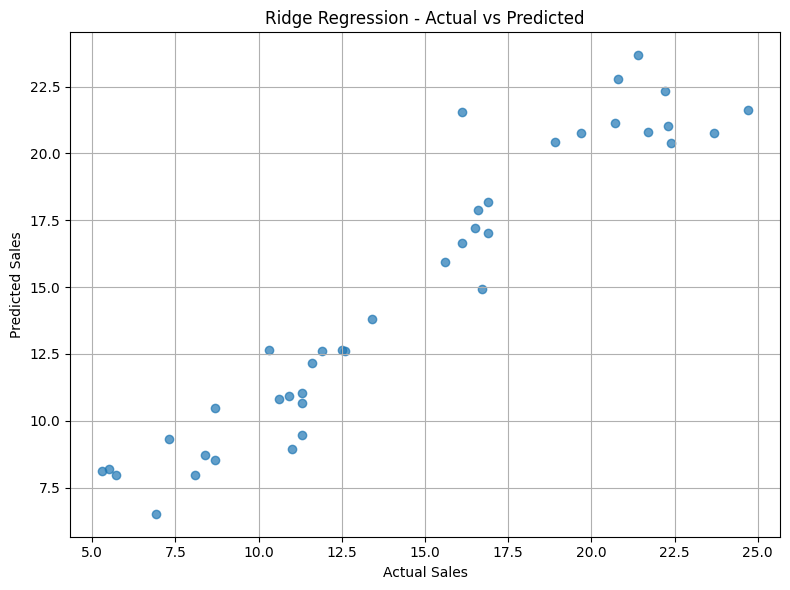

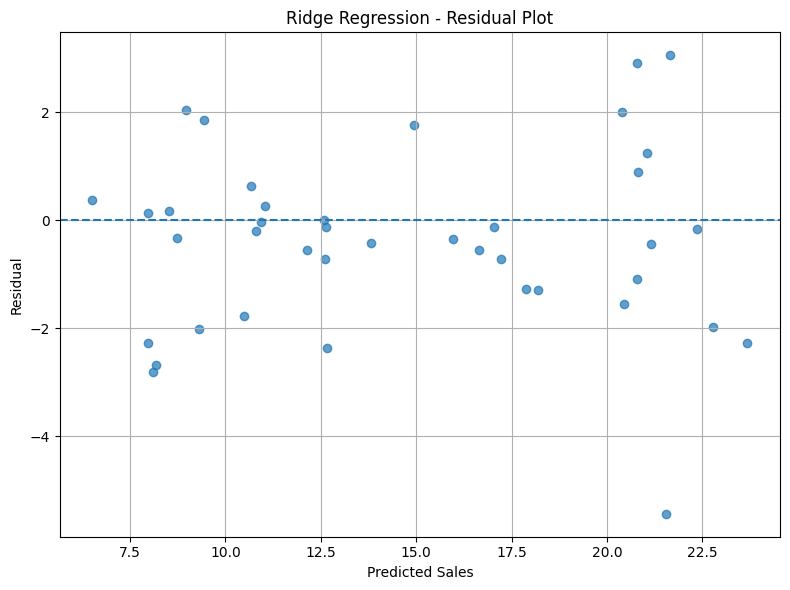


Actual vs Predicted Sales:
   Actual Sales  Predicted Sales
0          16.9        17.028922
1          22.4        20.383256
2          21.4        23.675270
3           7.3         9.312908
4          24.7        21.638558
5          12.6        12.590841
6          22.3        21.045484
7           8.4         8.728674
8          16.5        17.221971
9          16.1        16.658708


In [6]:
# ============================================================
# RIDGE REGRESSION - SALES PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("SalesPredict.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. SEPARATE FEATURES AND TARGET
# ============================================================

X = df[
    ["TV", "Radio", "Newspaper"]
]

y = df["Sales"]


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 5. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 6. CREATE RIDGE REGRESSION MODEL
# ============================================================

model = Ridge(
    alpha=1.0
)


# ============================================================
# 7. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 9. MODEL EVALUATION
# ============================================================

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


# ============================================================
# 10. DISPLAY RESULTS
# ============================================================

print("\n========================================")
print("RIDGE REGRESSION RESULTS")
print("========================================")

print(f"R² Score       : {r2:.4f}")
print(f"R² Score (%)   : {r2 * 100:.2f}%")
print(f"MAE            : {mae:.4f}")
print(f"RMSE           : {rmse:.4f}")


# ============================================================
# 11. BAR CHART - MODEL METRICS
# ============================================================

metrics = [
    "R² Score (%)",
    "MAE",
    "RMSE"
]

values = [
    r2 * 100,
    mae,
    rmse
]

plt.figure(figsize=(8, 5))

plt.bar(
    metrics,
    values
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Value")

plt.title(
    "Ridge Regression - Model Performance"
)

for i, value in enumerate(values):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 12. LINE CHART - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    y_pred,
    marker="x",
    label="Predicted Sales"
)

plt.xlabel("Test Data Samples")
plt.ylabel("Sales")

plt.title(
    "Ridge Regression - Actual vs Predicted Sales"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 13. SCATTER PLOT - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.title(
    "Ridge Regression - Actual vs Predicted"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 14. RESIDUAL PLOT
# ============================================================

residuals = y_test.values - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Sales"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Ridge Regression - Residual Plot"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 15. ACTUAL VS PREDICTED TABLE
# ============================================================

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print("\nActual vs Predicted Sales:")
print(comparison.head(10))